In [1]:
import numpy as np
from scipy.sparse import spdiags, eye, kron
from scipy.sparse.linalg import spsolve, cg, LinearOperator
import scipy.sparse.linalg as splinalg
import matplotlib.pyplot as plt
import numba

In [2]:
def Amult(U, m):
    AU = np.pad(U.reshape((m, m)), ((1,1), (1,1)), 'constant')
    AU[1:-1, 1:-1] = \
        AU[:-2, 1:-1] + \
        AU[1:-1, :-2] + \
        AU[2:, 1:-1] + \
        AU[1:-1, 2:] - \
        4 * AU[1:-1, 1:-1] 
    return - (1+m)**2 * AU[1:-1, 1:-1].reshape(-1)

U = np.array([1,2,3,4])
m = 2
Amult(U, m)

array([-9, 27, 63, 99])

In [3]:
def u_func(x,y):
    return np.sin(4*np.pi*(x+y)) + np.cos(4*np.pi*x*y)

def f_func(x,y):
    term1 = -32*np.pi**2*np.sin(4*np.pi*(x+y))
    term2 = -16*np.pi**2*(x**2 + y**2)*np.cos(4*np.pi*x*y)
    return term1 + term2

def form_rhs(m, f_func, u_func):

    h = 1.0/(m+1)
    b = np.zeros(m*m)

    for j in range(1, m+1):
        for i in range(1, m+1):

            k = (j-1)*m + (i-1)
            x = i*h
            y = j*h

            b[k] = f_func(x,y)

            # left boundary
            if i == 1:
                b[k] -= u_func(0,y)/h**2

            # right boundary
            if i == m:
                b[k] -= u_func(1,y)/h**2

            # bottom boundary
            if j == 1:
                b[k] -= u_func(x,0)/h**2

            # top boundary
            if j == m:
                b[k] -= u_func(x,1)/h**2

    return b

Successful


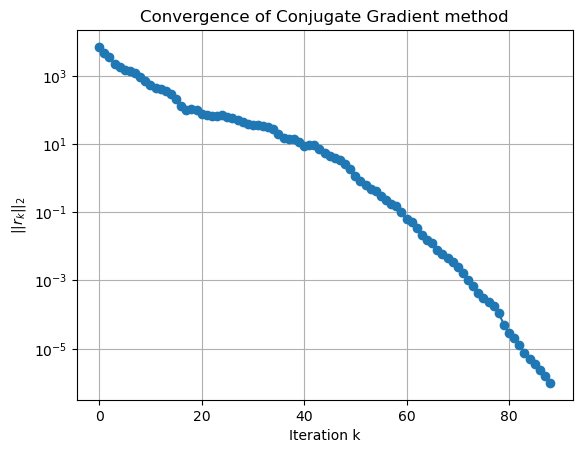

In [4]:

#ms = [3, 4, 10, 25, 50]
m = 25

errs = []


h = 1 / (m + 1)

F = form_rhs(m,f_func,u_func)
Aminus = LinearOperator(
    shape=(m**2, m**2), 
    matvec=lambda U: Amult(U, m),
    dtype=np.float64
)

residual_norms = []
def residual_norm(xk):
    r_norm = np.linalg.norm(F + Aminus @ xk)
    residual_norms.append(r_norm)

v, info = cg(Aminus, -F, rtol = 1e-10, callback = residual_norm)
print(f"{"Successful" if info == 0 else str(info) + " iterations"}")

plt.semilogy(residual_norms, 'o-')
plt.xlabel("Iteration k")
plt.ylabel(r"$||r_k||_2$")
plt.grid(True, which='both')
plt.title("Convergence of Conjugate Gradient method")
plt.show()

Relaxed iteration matrix:
$$
G_{\omega} = (1 - \omega) I + \omega G
$$

where OG iteration matrix in Jacobi iterations is
$$
G_J = I - D^{-1}A
$$
with $A$ is the system matrix for the discretized system.

Eigenvalues of iteration matrix $G$ from Leveque:
$$
\lambda_{p,q} = 
$$

In [5]:
def eigen_part(h, p, q):
    # G = I + D**(-1) * A => lmb = 1 + h**2 / 4 (2 / h**2 * lmb(A))
    #                      => lmb = 1 + lmb(A)
    return 1 + 0.5 * (np.cos(p*np.pi*h) + np.cos(q*np.pi*h) - 2)

def gamma(eigen_part, omegas):
    shape_form = (*omegas.shape, *eigen_part.shape)
    g = np.empty(shape_form)
    for i,w in enumerate(omegas):
        g[i] = 1 - w + w * eigen_part

    return g

    # return np.ones_like(omegas) - omegas + omegas * eigen_part

For 30 min rho (0.37355138780785335) is at omega = 0.6938775510204082
For 60 min rho (0.36375373952978857) is at omega = 0.6530612244897959
For 200 min rho (0.35204233636074056) is at omega = 0.6530612244897959


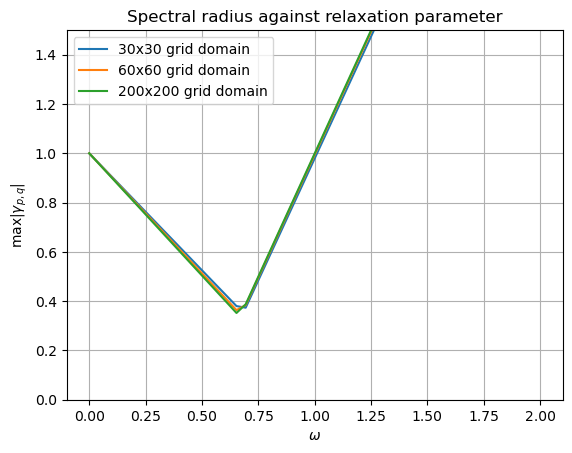

In [6]:
omega = np.linspace(0, 2, 50)
for m in [30, 60, 200]:
    h = 1 / (m + 1)
    p = np.arange(m//2, m)
    q = np.arange(m//2, m)
    P, Q = np.meshgrid(p, q)
    ep = eigen_part(h, P, Q)
    max_gamma_at_w = np.max(np.abs(gamma(ep, omega)), axis=(1,2))
    print(f"For {m} min rho ({np.min(max_gamma_at_w)}) is at omega = {omega[np.argmin(max_gamma_at_w)]}")
    plt.plot(omega, max_gamma_at_w, label=f"{m}x{m} grid domain")

plt.xlabel(r'$\omega$')
plt.ylabel(r'$\max |\gamma_{p,q}|$')
plt.ylim(0, 1.5)
plt.grid()
plt.title('Spectral radius against relaxation parameter')
plt.legend()
plt.show()

In [7]:
def coarsen(R, m):
    mc = m // 2
    Rc = np.empty(mc**2)

    # Half weighting
    for kc in range(mc**2):
        '''
            ic = kc % mc
            jc = kc // mc
            k = 2ic + 2*jc*m 
            k = 2*kc
            k = i + j*m = 2*kc
            (i ± 1, j) = k ± 1 = 2*kc ± 1
            (i, j ± 1) = k ± m = 2*kc ± m
        '''

        ic, jc = kc % mc, kc // mc
        k = 2 * ic + 2 * jc * m

        center = U[k]
        left  = U[k-1]   if 2*ic > 0     else 0.0
        right = U[k+1]   if 2*ic < m-1   else 0.0
        up  = U[k-m]   if 2*jc > 0     else 0.0
        down    = U[k+m]   if 2*jc < m-1   else 0.0
        
        Rc[kc] = 1 / 8 * (
            left # (i - 1, j)
            + up # (i, j - 1)
            + 4 * center # (i, j)
            + down # (i, j + 1)
            + right # (i + 1, j)
        )
    return Rc

In [8]:
m = 4
U = np.arange(m**2)
coarsen(U, m)

array([ 0.625,  2.25 ,  7.125, 10.   ])

In [9]:
test = np.zeros(m**2)
Uc = coarsen(U, m).reshape(m // 2, m // 2)
test, Uc

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([[ 0.625,  2.25 ],
        [ 7.125, 10.   ]]))

In [11]:
mc = m // 2
test.reshape(m,m)[::2, ::2] = Uc
for k in range(test.size):
    i = k % m
    j = k // m
    if (i % 2 == 0) and (j % 2 == 0):
        continue
    if (i % 2 == 0):
        up = Uc[i // 2, (j - 1) // 2]
        down = Uc[i // 2, (j + 1) // 2]
        test[i + j*m] = 0.5 * (up + down)
    if (j % 2 == 0):
        left = Uc[(i - 1) // 2, j // 2]
        right = Uc[(i + 1) // 2, j // 2]
        test[i + j*m] = 0.5 * (left + right)
test


IndexError: index 2 is out of bounds for axis 0 with size 2